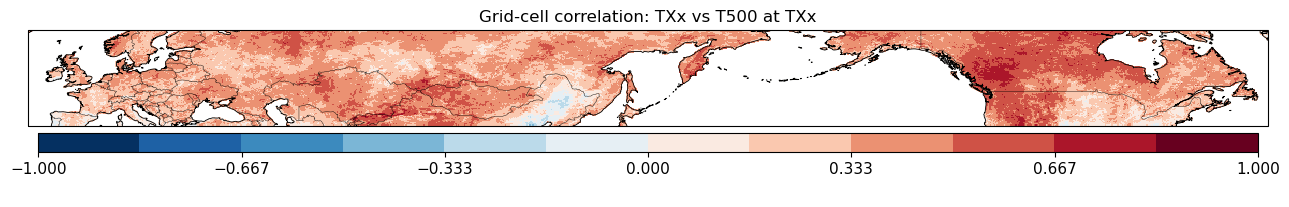

In [38]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]
t500 = ds_band["t_at_tasmax"]

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")

txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Correlation per grid cell
# -----------------------
r = xr.corr(txx, t500, dim="year")

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
r_land = r.where(land_mask)

# -----------------------
# Plot correlation map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Plot WITHOUT automatic colorbar
im = r_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1, vmax=1, levels = 13,
    add_colorbar=False
)

ax.set_title("Grid-cell correlation: TXx vs T500 at TXx")

# Horizontal colorbar below
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

cbar.set_label(" ", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig("T500_at_tasmax_vs_TXX_correlation_map.png", dpi=300, bbox_inches="tight")
plt.show()


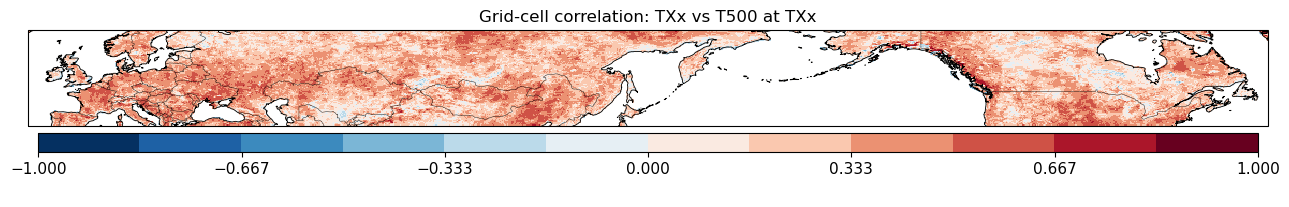

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]
t500 = ds_band["blh_at_tasmax"]

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")

txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Correlation per grid cell
# -----------------------
r = xr.corr(txx, t500, dim="year")

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
r_land = r.where(land_mask)

# -----------------------
# Plot correlation map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Plot WITHOUT automatic colorbar
im = r_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1, vmax=1, levels = 13,
    add_colorbar=False
)

ax.set_title("Grid-cell correlation: TXx vs BLH at TXx")

# Horizontal colorbar below
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

cbar.set_label(" ", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig("blh_at_tasmax_vs_TXX_correlation_map.png", dpi=300, bbox_inches="tight")
plt.show()


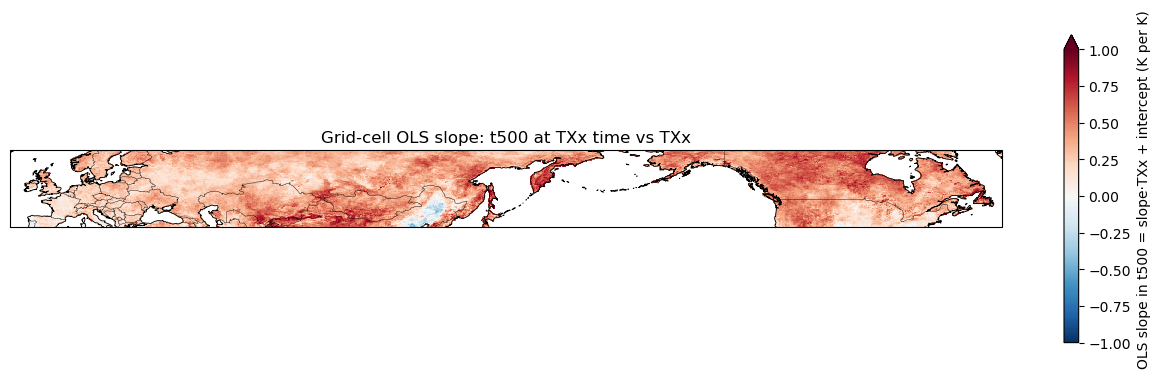

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from scipy import stats

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]          # (year, lat, lon)
t500 = ds_band["t_at_tasmax"]  # (year, lat, lon)

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")
txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Actual OLS fit per grid cell using scipy.stats.linregress
# -----------------------
def linregress_1d(x, y):
    """Return slope, intercept, r, p, stderr for 1D arrays (time)."""
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < min_n:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)
    res = stats.linregress(x[m], y[m])
    return (res.slope, res.intercept, res.rvalue, res.pvalue, res.stderr)

slope, intercept, rvalue, pvalue, stderr = xr.apply_ufunc(
    linregress_1d,
    txx, t500,
    input_core_dims=[["year"], ["year"]],
    output_core_dims=[[], [], [], [], []],
    vectorize=True,
    dask="parallelized",          # safe even if not dask-backed
    output_dtypes=[float, float, float, float, float],
)

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

slope_land = slope.where(land_mask)

# -----------------------
# Plot slope map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = slope_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    add_colorbar=True, vmin=-1, vmax =1,
    cbar_kwargs={"label": "OLS slope in t500 = slope·TXx + intercept (K per K)"},
)

ax.set_title("Grid-cell OLS slope: t500 at TXx time vs TXx")

plt.savefig("T500_vs_TXX_OLS_slope_map.png", dpi=300, bbox_inches="tight")
plt.show()


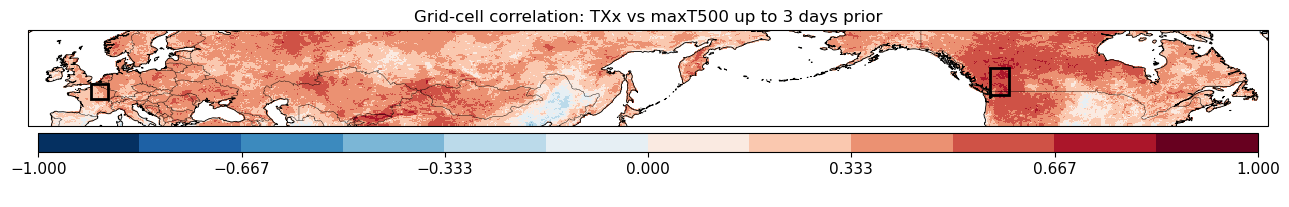

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]
t500 = ds_band["t500_premax_3d"]

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")

txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Correlation per grid cell
# -----------------------
r = xr.corr(txx, t500, dim="year")

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
r_land = r.where(land_mask)

# -----------------------
# Plot correlation map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Plot WITHOUT automatic colorbar
im = r_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1, vmax=1, levels = 13,
    add_colorbar=False
)

ax.set_title("Grid-cell correlation: TXx vs maxT500 up to 3 days prior")

# Horizontal colorbar below
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

import matplotlib.patches as mpatches

# -----------------------
# Define boxes
# -----------------------

# Box 1 (Europe)
lon0_1, lon1_1 = 1.5, 6
lat0_1, lat1_1 = 47.0, 51.0

# Box 2 (W. North America, already in 0–360)
lon0_2, lon1_2 = 360 - 123, 360 - 118  # 237–242
lat0_2, lat1_2 = 48, 55

# -----------------------
# Add rectangles
# -----------------------

rect1 = mpatches.Rectangle(
    (lon0_1, lat0_1),
    lon1_1 - lon0_1,
    lat1_1 - lat0_1,
    linewidth=2,
    edgecolor="black",
    facecolor="none",
    transform=data_crs,
    zorder=6
)

rect2 = mpatches.Rectangle(
    (lon0_2, lat0_2),
    lon1_2 - lon0_2,
    lat1_2 - lat0_2,
    linewidth=2,
    edgecolor="black",
    facecolor="none",
    transform=data_crs,
    zorder=6
)

ax.add_patch(rect1)
ax.add_patch(rect2)

cbar.set_label(" ", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig("t500premax_at_tasmax_vs_TXX_correlation_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from scipy import stats

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]          # (year, lat, lon)
t500 = ds_band["t500_premax_3d"]  # (year, lat, lon)

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")
txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Actual OLS fit per grid cell using scipy.stats.linregress
# -----------------------
def linregress_1d(x, y):
    """Return slope, intercept, r, p, stderr for 1D arrays (time)."""
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < min_n:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)
    res = stats.linregress(x[m], y[m])
    return (res.slope, res.intercept, res.rvalue, res.pvalue, res.stderr)

slope, intercept, rvalue, pvalue, stderr = xr.apply_ufunc(
    linregress_1d,
    txx, t500,
    input_core_dims=[["year"], ["year"]],
    output_core_dims=[[], [], [], [], []],
    vectorize=True,
    dask="parallelized",          # safe even if not dask-backed
    output_dtypes=[float, float, float, float, float],
)

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

slope_land = slope.where(land_mask)

# -----------------------
# Plot slope map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = slope_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    add_colorbar=True, vmin=-1, vmax =1,
    cbar_kwargs={"label": "OLS slope in t500 = slope·TXx + intercept (K per K)"},
)

ax.set_title("Grid-cell OLS slope: maxt500 up to 3 days prior to TXx time vs TXx")

plt.savefig("t500_premax_3d_vs_TXX_OLS_slope_map.png", dpi=300, bbox_inches="tight")
plt.show()


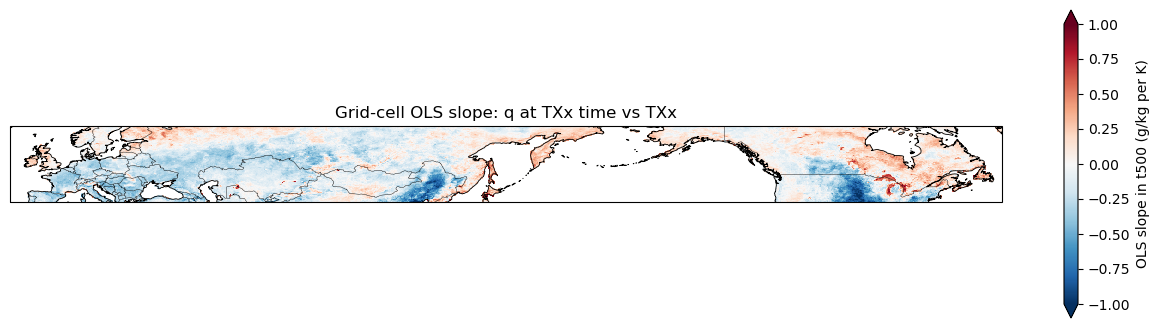

In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from scipy import stats

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]          # (year, lat, lon)
t500 = ds_band["q_at_tasmax"]*1000  # (year, lat, lon)

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")
txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Actual OLS fit per grid cell using scipy.stats.linregress
# -----------------------
def linregress_1d(x, y):
    """Return slope, intercept, r, p, stderr for 1D arrays (time)."""
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < min_n:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)
    res = stats.linregress(x[m], y[m])
    return (res.slope, res.intercept, res.rvalue, res.pvalue, res.stderr)

slope, intercept, rvalue, pvalue, stderr = xr.apply_ufunc(
    linregress_1d,
    txx, t500,
    input_core_dims=[["year"], ["year"]],
    output_core_dims=[[], [], [], [], []],
    vectorize=True,
    dask="parallelized",          # safe even if not dask-backed
    output_dtypes=[float, float, float, float, float],
)

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

slope_land = slope.where(land_mask)

# -----------------------
# Plot slope map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = slope_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    add_colorbar=True, vmin=-1, vmax =1,
    cbar_kwargs={"label": "OLS slope in t500 (g/kg per K)"},
)

ax.set_title("Grid-cell OLS slope: q at TXx time vs TXx")

plt.savefig("q_at_tasmax_vs_TXX_OLS_slope_map.png", dpi=300, bbox_inches="tight")
plt.show()


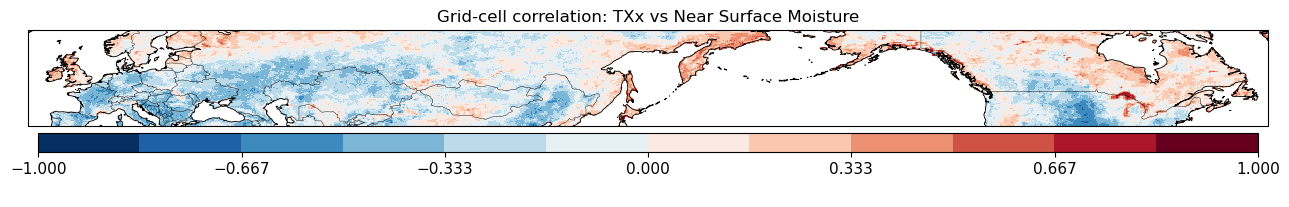

In [40]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
    txx  = ds_band["txx"]
t500 = ds_band["q_at_tasmax"]

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")

txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Correlation per grid cell
# -----------------------
r = xr.corr(txx, t500, dim="year")

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
r_land = r.where(land_mask)

# -----------------------
# Plot correlation map (horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Plot WITHOUT automatic colorbar
im = r_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1, vmax=1, levels = 13,
    add_colorbar=False
)

ax.set_title("Grid-cell correlation: TXx vs Near Surface Moisture")

# Horizontal colorbar below
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

cbar.set_label(" ", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig("q_at_tasmax_vs_TXX_correlation_map.png", dpi=300, bbox_inches="tight")
plt.show()


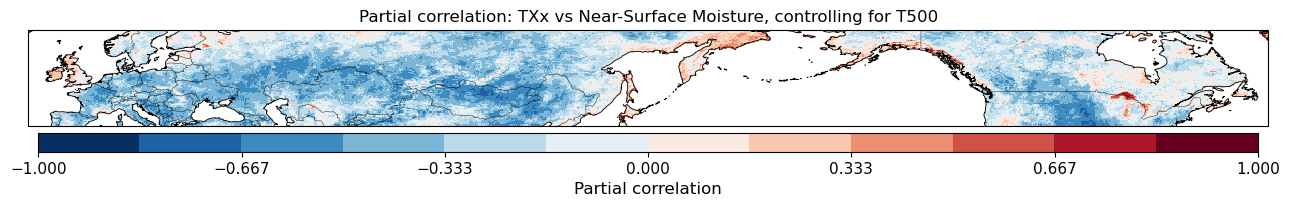

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]
q    = ds_band["q_at_tasmax"]
t500 = ds_band["t500_premax_3d"]   # control variable

txx, q, t500 = xr.align(txx, q, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20

valid = np.isfinite(txx) & np.isfinite(q) & np.isfinite(t500)
nvalid = valid.sum("year")

txx  = txx.where(valid)
q    = q.where(valid)
t500 = t500.where(valid)

txx  = txx.where(nvalid >= min_n)
q    = q.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Partial correlation per grid cell
# TXx vs q_at_tasmax, controlling for t500_premax_3d
# -----------------------
r_txx_q    = xr.corr(txx, q, dim="year")
r_txx_t500 = xr.corr(txx, t500, dim="year")
r_q_t500   = xr.corr(q, t500, dim="year")

r = (
    (r_txx_q - r_txx_t500 * r_q_t500)
    / np.sqrt((1 - r_txx_t500**2) * (1 - r_q_t500**2))
)

r = r.where(np.isfinite(r))

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = land.mask(ds_band["lon"], ds_band["lat"]) == 0

r_land = r.where(land_mask)

# -----------------------
# Plot partial correlation map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = r_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    levels=13,
    add_colorbar=False
)

ax.set_title("Partial correlation: TXx vs Near-Surface Moisture, controlling for T500")

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

cbar.set_label("Partial correlation", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig(
    "q_at_tasmax_vs_TXX_partial_correlation_control_T500.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

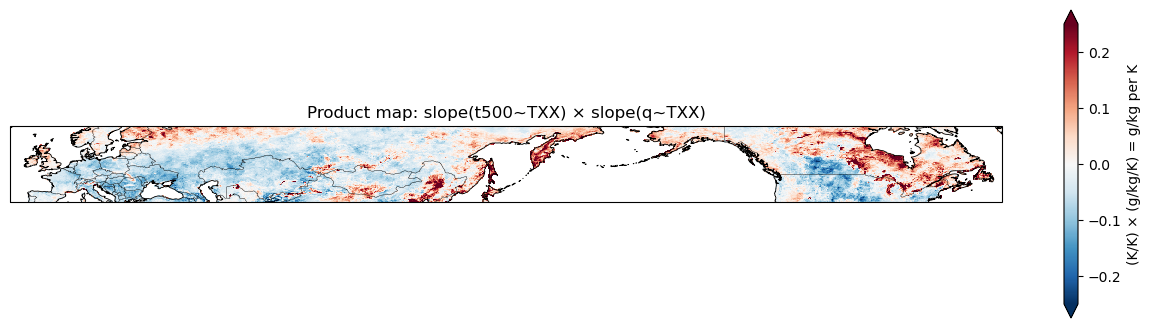

In [6]:
# product typically has smaller numbers; start with symmetric limits and adjust after first look
plot_map(
    slope_product_land,
    "Product map: slope(t500~TXX) × slope(q~TXX)",
    "(K/K) × (g/kg/K) = g/kg per K",
    "product_slope_t500_times_q.png",
    vmin=-0.25, vmax=0.25
)


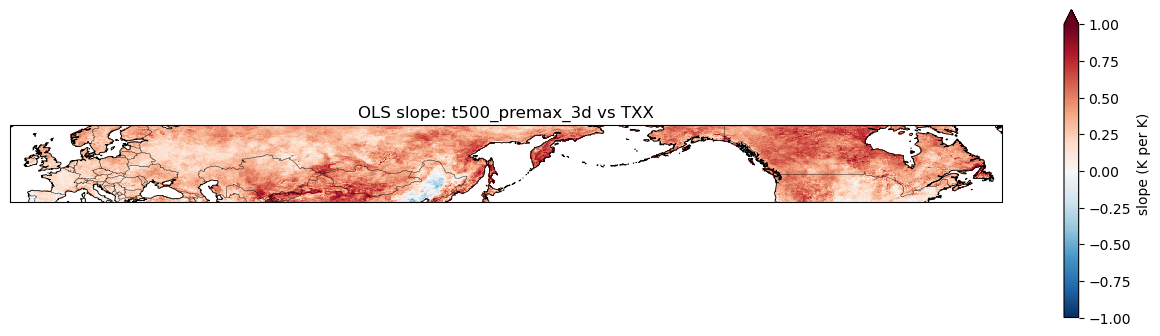

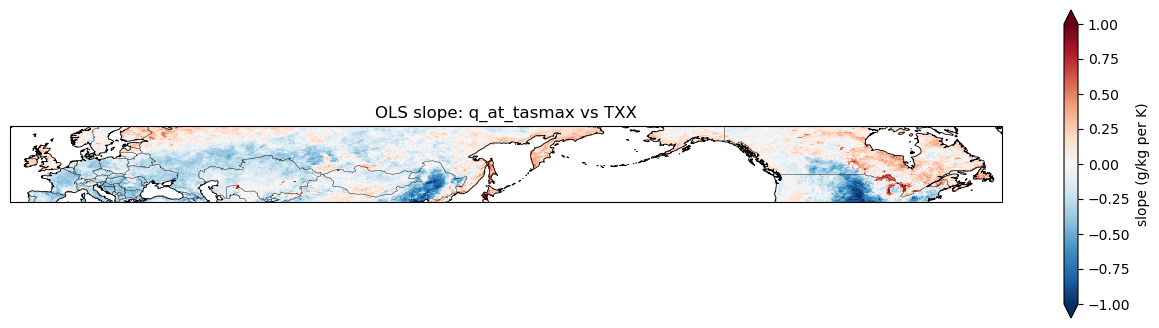

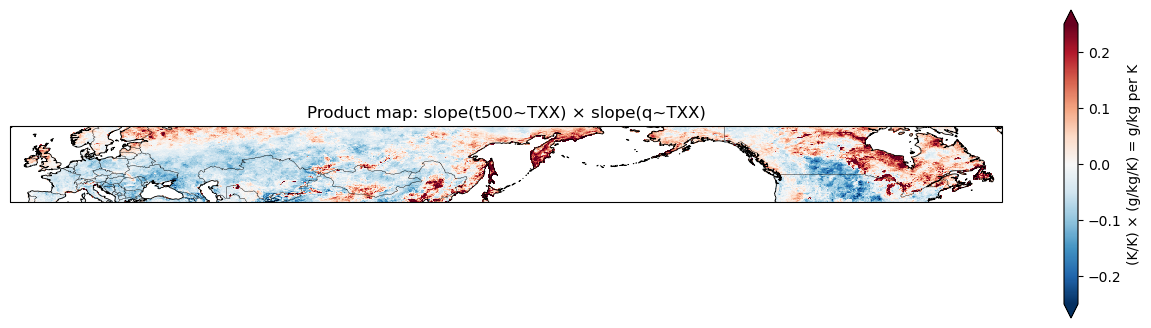

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from scipy import stats

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables (aligned)
# -----------------------
txx   = ds_band["txx"]                       # (year, lat, lon)
t500K = ds_band["t_at_tasmax"]            # (year, lat, lon)  [K]
qgkg  = ds_band["q_at_tasmax"] * 1000.0      # (year, lat, lon)  [g/kg]

txx, t500K, qgkg = xr.align(txx, t500K, qgkg, join="inner")

# -----------------------
# Require at least N valid years per grid cell (based on ALL vars)
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500K) & np.isfinite(qgkg)).sum("year")
txx   = txx.where(nvalid >= min_n)
t500K = t500K.where(nvalid >= min_n)
qgkg  = qgkg.where(nvalid >= min_n)

# -----------------------
# OLS slope per grid cell: y = slope*x + intercept
# -----------------------
def linregress_slope_1d(x, y, min_n=20):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < min_n:
        return np.nan
    return stats.linregress(x[m], y[m]).slope

def slope_map(x, y, min_n=20):
    return xr.apply_ufunc(
        linregress_slope_1d,
        x, y,
        kwargs={"min_n": min_n},
        input_core_dims=[["year"], ["year"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

slope_t500 = slope_map(txx, t500K, min_n=min_n)   # K per K
slope_q    = slope_map(txx, qgkg,  min_n=min_n)   # g/kg per K

# -----------------------
# Product map
# -----------------------
slope_product = (slope_t500 * slope_q).rename("slope_product")
slope_product.attrs["description"] = "Product: slope(t500~TXX) * slope(q~TXX)"

# -----------------------
# Land mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

slope_t500_land    = slope_t500.where(land_mask)
slope_q_land       = slope_q.where(land_mask)
slope_product_land = slope_product.where(land_mask)

# -----------------------
# Plot helper
# -----------------------
def plot_map(da, title, cbar_label, fname, vmin=None, vmax=None, cmap="RdBu_r"):
    proj = ccrs.PlateCarree(central_longitude=135)
    data_crs = ccrs.PlateCarree()

    fig = plt.figure(figsize=(16, 4))
    ax = plt.axes(projection=proj)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    lonL, lonR = -15, 310
    ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

    im = da.plot(
        ax=ax, transform=data_crs, x="lon", y="lat",
        cmap=cmap, vmin=vmin, vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={"label": cbar_label},
    )

    ax.set_title(title)
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------
# Make the 3 maps (optional, but useful)
# -----------------------
plot_map(
    slope_t500_land,
    "OLS slope: t500_premax_3d vs TXX",
    "slope (K per K)",
    "t_at_tasmax_vs_TXX_slope.png",
    vmin=-1, vmax=1
)

plot_map(
    slope_q_land,
    "OLS slope: q_at_tasmax vs TXX",
    "slope (g/kg per K)",
    "q_at_tasmax_vs_TXX_slope.png",
    # pick a sensible range for q slopes; adjust after first look
    vmin=-1, vmax=1
)

# product typically has smaller numbers; start with symmetric limits and adjust after first look
plot_map(
    slope_product_land,
    "Product map: slope(t500~TXX) × slope(q~TXX)",
    "(K/K) × (g/kg/K) = g/kg per K",
    "product_slope_t500_at_tasmax_times_q.png",
    vmin=-0.25, vmax=0.25
)


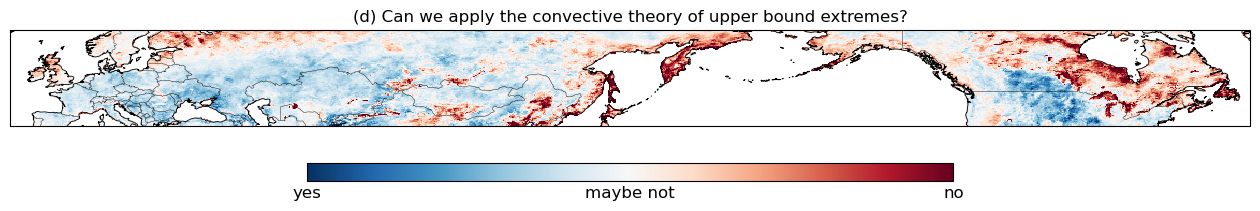

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from scipy import stats

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables (aligned)
# -----------------------
txx   = ds_band["txx"]                       # (year, lat, lon)
t500K = ds_band["t_at_tasmax"]            # (year, lat, lon)  [K]
qgkg  = ds_band["q_at_tasmax"] * 1000.0      # (year, lat, lon)  [g/kg]

txx, t500K, qgkg = xr.align(txx, t500K, qgkg, join="inner")

# -----------------------
# Require at least N valid years per grid cell (based on ALL vars)
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500K) & np.isfinite(qgkg)).sum("year")
txx   = txx.where(nvalid >= min_n)
t500K = t500K.where(nvalid >= min_n)
qgkg  = qgkg.where(nvalid >= min_n)

# -----------------------
# OLS slope per grid cell: y = slope*x + intercept
# -----------------------
def linregress_slope_1d(x, y, min_n=20):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < min_n:
        return np.nan
    return stats.linregress(x[m], y[m]).slope

def slope_map(x, y, min_n=20):
    return xr.apply_ufunc(
        linregress_slope_1d,
        x, y,
        kwargs={"min_n": min_n},
        input_core_dims=[["year"], ["year"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

slope_t500 = slope_map(txx, t500K, min_n=min_n)   # K per K
slope_q    = slope_map(txx, qgkg,  min_n=min_n)   # g/kg per K

# -----------------------
# Product map
# -----------------------
slope_product = (slope_t500 * slope_q).rename("slope_product")
slope_product.attrs["description"] = "Product: slope(t500~TXX) * slope(q~TXX)"

# -----------------------
# Land mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

slope_t500_land    = slope_t500.where(land_mask)
slope_q_land       = slope_q.where(land_mask)
slope_product_land = slope_product.where(land_mask)

# -----------------------
# Plot ONLY the product map (with horizontal colorbar + custom tick labels)
# -----------------------
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_product_map_with_custom_cbar(
    da,
    fname,
    vmin=-0.25,
    vmax=0.25,
    cmap="RdBu_r"
):
    proj = ccrs.PlateCarree(central_longitude=135)
    data_crs = ccrs.PlateCarree()

    fig = plt.figure(figsize=(16, 4))
    ax = plt.axes(projection=proj)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    lonL, lonR = -15, 310
    ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

    # Plot WITHOUT xarray's auto colorbar
    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )

    ax.set_title("(d) Can we apply the convective theory of upper bound extremes?")

    # Horizontal colorbar below
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.12,        # distance from plot
        fraction=0.06,   # thickness
        aspect=35
    )

    # Refined ticks + labels (blue end is vmin for RdBu_r; red end is vmax)
    ticks = [vmin, 0.0, vmax]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(["yes", "maybe not", "no"])

    # Optional: make labels a bit cleaner visually
    cbar.ax.tick_params(length=0, labelsize=12)

    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

plot_product_map_with_custom_cbar(
    slope_product_land,
    fname="product_slope_t500_at_tasmax_times_q.png",
    vmin=-0.25,
    vmax=0.25,
    cmap="RdBu_r"
)


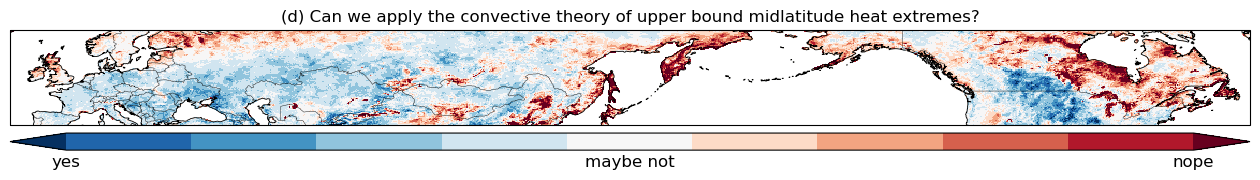

In [13]:
def plot_product_map_with_custom_cbar(
    da,
    fname,
    vmin=-0.25,
    vmax=0.25,
    cmap="RdBu_r"
):
    proj = ccrs.PlateCarree(central_longitude=135)
    data_crs = ccrs.PlateCarree()

    fig = plt.figure(figsize=(16, 4))
    ax = plt.axes(projection=proj)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    lonL, lonR = -15, 310
    ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

    # Plot WITHOUT xarray's auto colorbar
    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax, levels = 10,
        add_colorbar=False,
    )

    ax.set_title("(d) Can we apply the convective theory of upper bound midlatitude heat extremes?")

    # Horizontal colorbar below
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.025,        # distance from plot
        fraction=0.06,   # thickness
        aspect=66
    )

    # Refined ticks + labels (blue end is vmin for RdBu_r; red end is vmax)
    ticks = [vmin, 0.0, vmax]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(["yes", "maybe not", "nope"])

    # Optional: make labels a bit cleaner visually
    cbar.ax.tick_params(length=0, labelsize=12)

    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

plot_product_map_with_custom_cbar(
    slope_product_land,
    fname="product_slope_t500_at_tasmax_times_q.png",
    vmin=-0.2,
    vmax=0.2,
    cmap="RdBu_r"
)

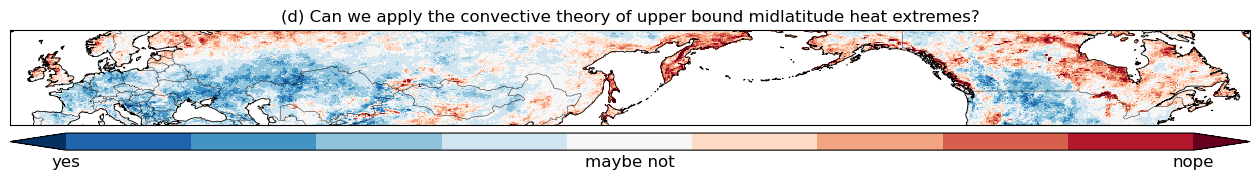

In [21]:
# -----------------------
# Correlation map (ONLY) with horizontal colorbar + custom tick labels
# -----------------------
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables (aligned)
# -----------------------
txx   = ds_band["txx"]                       # (year, lat, lon)
t500K = ds_band["t_at_tasmax"]               # (year, lat, lon)  [K]
qgkg  = ds_band["q_at_tasmax"] * 1000.0      # (year, lat, lon)  [g/kg]

txx, t500K, qgkg = xr.align(txx, t500K, qgkg, join="inner")

# -----------------------
# Require at least N valid years per grid cell (based on ALL vars)
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500K) & np.isfinite(qgkg)).sum("year")
txx   = txx.where(nvalid >= min_n)
t500K = t500K.where(nvalid >= min_n)
qgkg  = qgkg.where(nvalid >= min_n)

# -----------------------
# Correlations (per grid cell)
# -----------------------
# Pearson r across "year"
corr_t500 = xr.corr(t500K, txx, dim="year").rename("corr_t500_txx")
corr_q    = xr.corr(qgkg,  txx, dim="year").rename("corr_q_txx")

# Correlation "product" (as analogue to your slope product)
corr_product = (corr_t500 * corr_q).rename("corr_product")
corr_product.attrs["description"] = "Product: corr(t500, TXX) * corr(q, TXX)"

# -----------------------
# Land mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

corr_product_land = corr_product.where(land_mask)

# -----------------------
# Plot helper (ONLY correlation product map)
# -----------------------
def plot_corr_map_with_custom_cbar(
    da,
    fname,
    vmin=-1.0,
    vmax=1.0,
    cmap="RdBu_r",
    levels=10
):
    proj = ccrs.PlateCarree(central_longitude=135)
    data_crs = ccrs.PlateCarree()

    fig = plt.figure(figsize=(16, 4))
    ax = plt.axes(projection=proj)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    lonL, lonR = -15, 310
    ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False,
    )

    ax.set_title("(d) Can we apply the convective theory of upper bound midlatitude heat extremes?")

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.025,
        fraction=0.06,
        aspect=66
    )

    ticks = [vmin, 0.0, vmax]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(["yes", "maybe not", "nope"])
    cbar.ax.tick_params(length=0, labelsize=12)

    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

plot_corr_map_with_custom_cbar(
    corr_product_land,
    fname="corr_product_t500_at_tasmax_times_q_vs_TXX.png",
    vmin=-0.25,
    vmax=0.25,
    cmap="RdBu_r",
    levels=10
)


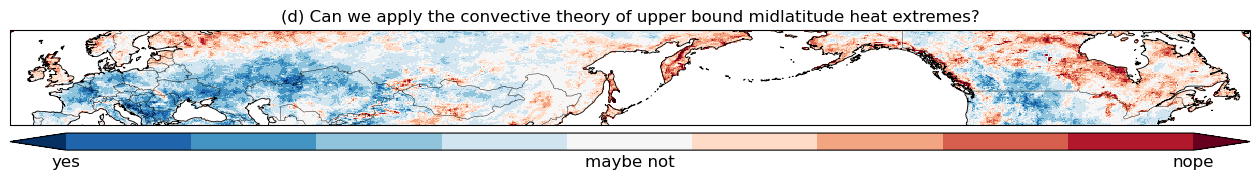

In [24]:
# -----------------------
# Correlation map (ONLY) with horizontal colorbar + custom tick labels
# -----------------------
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables (aligned)
# -----------------------
txx   = ds_band["txx"]                       # (year, lat, lon)
t500K = ds_band["t500_premax_3d"]               # (year, lat, lon)  [K]
qgkg  = ds_band["q_at_tasmax"] * 1000.0      # (year, lat, lon)  [g/kg]

txx, t500K, qgkg = xr.align(txx, t500K, qgkg, join="inner")

# -----------------------
# Require at least N valid years per grid cell (based on ALL vars)
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500K) & np.isfinite(qgkg)).sum("year")
txx   = txx.where(nvalid >= min_n)
t500K = t500K.where(nvalid >= min_n)
qgkg  = qgkg.where(nvalid >= min_n)

# -----------------------
# Correlations (per grid cell)
# -----------------------
# Pearson r across "year"
corr_t500 = xr.corr(t500K, txx, dim="year").rename("corr_t500_txx")
corr_q    = xr.corr(qgkg,  txx, dim="year").rename("corr_q_txx")

# Correlation "product" (as analogue to your slope product)
corr_product = (corr_t500 * corr_q).rename("corr_product")
corr_product.attrs["description"] = "Product: corr(t500, TXX) * corr(q, TXX)"

# -----------------------
# Land mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

corr_product_land = corr_product.where(land_mask)

# -----------------------
# Plot helper (ONLY correlation product map)
# -----------------------
def plot_corr_map_with_custom_cbar(
    da,
    fname,
    vmin=-1.0,
    vmax=1.0,
    cmap="RdBu_r",
    levels=10
):
    proj = ccrs.PlateCarree(central_longitude=135)
    data_crs = ccrs.PlateCarree()

    fig = plt.figure(figsize=(16, 4))
    ax = plt.axes(projection=proj)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    lonL, lonR = -15, 310
    ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False,
    )

    ax.set_title("(d) Can we apply the convective theory of upper bound midlatitude heat extremes?")

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.025,
        fraction=0.06,
        aspect=66
    )

    ticks = [vmin, 0.0, vmax]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(["yes", "maybe not", "nope"])
    cbar.ax.tick_params(length=0, labelsize=12)

    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

plot_corr_map_with_custom_cbar(
    corr_product_land,
    fname="corr_product_t500_at_tasmax_times_q_vs_TXX.png",
    vmin=-0.25,
    vmax=0.25,
    cmap="RdBu_r",
    levels=10
)


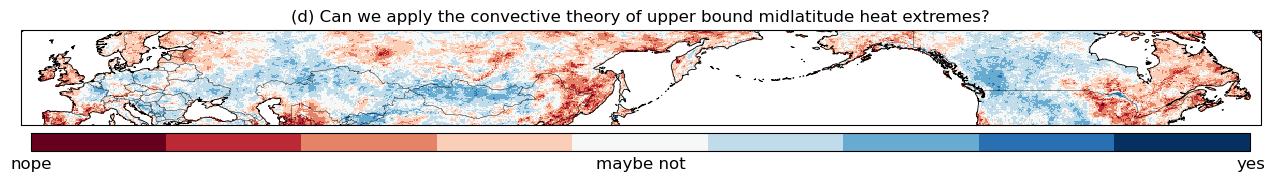

In [28]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables (aligned)
# -----------------------
txx   = ds_band["txx"]                      # (year, lat, lon)
t500K = ds_band["t500_premax_3d"]              # (year, lat, lon)  [K]
qgkg  = ds_band["q_at_tasmax"] * 1000.0     # (year, lat, lon)  [g/kg]

txx, t500K, qgkg = xr.align(txx, t500K, qgkg, join="inner")

# -----------------------
# Require at least N valid years per grid cell (based on ALL vars)
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500K) & np.isfinite(qgkg)).sum("year")
txx   = txx.where(nvalid >= min_n)
t500K = t500K.where(nvalid >= min_n)
qgkg  = qgkg.where(nvalid >= min_n)

# -----------------------
# Multiple correlation via multiple linear regression -> R^2
# y = a*x1 + b*x2 + c
# -----------------------
def multiple_r2_1d(y, x1, x2, min_n=20):
    m = np.isfinite(y) & np.isfinite(x1) & np.isfinite(x2)
    if m.sum() < min_n:
        return np.nan

    yy  = y[m].astype(float)
    xx1 = x1[m].astype(float)
    xx2 = x2[m].astype(float)

    # Design matrix with intercept
    X = np.column_stack([xx1, xx2, np.ones_like(xx1)])

    # Least squares
    beta, *_ = np.linalg.lstsq(X, yy, rcond=None)
    yhat = X @ beta

    sse = np.sum((yy - yhat)**2)
    sst = np.sum((yy - np.mean(yy))**2)
    if sst == 0:
        return np.nan

    r2 = 1.0 - sse / sst
    # numerical safety
    return float(np.clip(r2, 0.0, 1.0))

def multiple_r2_map(y, x1, x2, min_n=20):
    return xr.apply_ufunc(
        multiple_r2_1d,
        y, x1, x2,
        kwargs={"min_n": min_n},
        input_core_dims=[["year"], ["year"], ["year"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

r2_map = multiple_r2_map(txx, t500K, qgkg, min_n=min_n).rename("R2_txx_on_t500_q")
r2_map.attrs["description"] = "Multiple regression R^2 of TXX explained by (t500, q)"

# If you prefer multiple correlation R instead of R^2:
# r_map = np.sqrt(r2_map)

# -----------------------
# Land mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
r2_land = np.sqrt(r2_map.where(land_mask))

# -----------------------
# Plot ONLY (horizontal colorbar + custom tick labels)
# -----------------------
def plot_r2_with_custom_cbar(
    da,
    fname,
    vmin=0.0,
    vmax=1.0,
    cmap="RdBu_r",
    levels=10
):
    proj = ccrs.PlateCarree(central_longitude=135)
    data_crs = ccrs.PlateCarree()

    fig = plt.figure(figsize=(16, 4))
    ax = plt.axes(projection=proj)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    lonL, lonR = -15, 310
    ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False,
    )

    ax.set_title("(d) Can we apply the convective theory of upper bound midlatitude heat extremes?")

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.025,
        fraction=0.06,
        aspect=66
    )

    # For R^2: left=0 (weak) -> "nope", middle ~0.5 -> "maybe not", right=1 -> "yes"
    ticks = [vmin, 0.5*(vmin+vmax), vmax]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(["nope", "maybe not", "yes"])
    cbar.ax.tick_params(length=0, labelsize=12)

    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

plot_r2_with_custom_cbar(
    r2_land,
    fname="multiple_R2_TXX_on_t500_q.png",
    vmin=0.0,
    vmax=1.0,
    cmap="RdBu",
    levels=10
)


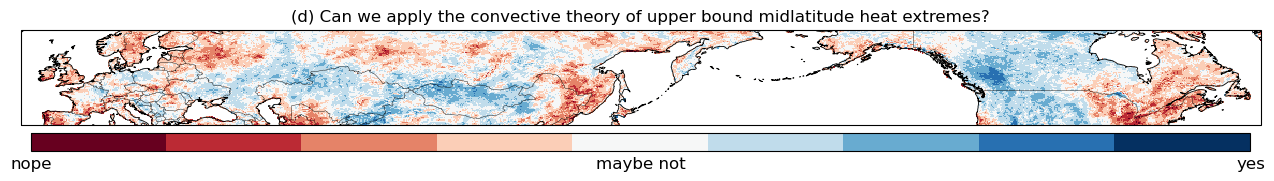

In [29]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables (aligned)
# -----------------------
txx   = ds_band["txx"]                      # (year, lat, lon)
t500K = ds_band["t_at_tasmax"]              # (year, lat, lon)  [K]
qgkg  = ds_band["q_at_tasmax"] * 1000.0     # (year, lat, lon)  [g/kg]

txx, t500K, qgkg = xr.align(txx, t500K, qgkg, join="inner")

# -----------------------
# Require at least N valid years per grid cell (based on ALL vars)
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500K) & np.isfinite(qgkg)).sum("year")
txx   = txx.where(nvalid >= min_n)
t500K = t500K.where(nvalid >= min_n)
qgkg  = qgkg.where(nvalid >= min_n)

# -----------------------
# Multiple correlation via multiple linear regression -> R^2
# y = a*x1 + b*x2 + c
# -----------------------
def multiple_r2_1d(y, x1, x2, min_n=20):
    m = np.isfinite(y) & np.isfinite(x1) & np.isfinite(x2)
    if m.sum() < min_n:
        return np.nan

    yy  = y[m].astype(float)
    xx1 = x1[m].astype(float)
    xx2 = x2[m].astype(float)

    # Design matrix with intercept
    X = np.column_stack([xx1, xx2, np.ones_like(xx1)])

    # Least squares
    beta, *_ = np.linalg.lstsq(X, yy, rcond=None)
    yhat = X @ beta

    sse = np.sum((yy - yhat)**2)
    sst = np.sum((yy - np.mean(yy))**2)
    if sst == 0:
        return np.nan

    r2 = 1.0 - sse / sst
    # numerical safety
    return float(np.clip(r2, 0.0, 1.0))

def multiple_r2_map(y, x1, x2, min_n=20):
    return xr.apply_ufunc(
        multiple_r2_1d,
        y, x1, x2,
        kwargs={"min_n": min_n},
        input_core_dims=[["year"], ["year"], ["year"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

r2_map = multiple_r2_map(txx, t500K, qgkg, min_n=min_n).rename("R2_txx_on_t500_q")
r2_map.attrs["description"] = "Multiple regression R^2 of TXX explained by (t500, q)"

# If you prefer multiple correlation R instead of R^2:
# r_map = np.sqrt(r2_map)

# -----------------------
# Land mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
r2_land = np.sqrt(r2_map.where(land_mask))

# -----------------------
# Plot ONLY (horizontal colorbar + custom tick labels)
# -----------------------
def plot_r2_with_custom_cbar(
    da,
    fname,
    vmin=0.0,
    vmax=1.0,
    cmap="RdBu_r",
    levels=10
):
    proj = ccrs.PlateCarree(central_longitude=135)
    data_crs = ccrs.PlateCarree()

    fig = plt.figure(figsize=(16, 4))
    ax = plt.axes(projection=proj)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    lonL, lonR = -15, 310
    ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False,
    )

    ax.set_title("(d) Can we apply the convective theory of upper bound midlatitude heat extremes?")

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.025,
        fraction=0.06,
        aspect=66
    )

    # For R^2: left=0 (weak) -> "nope", middle ~0.5 -> "maybe not", right=1 -> "yes"
    ticks = [vmin, 0.5*(vmin+vmax), vmax]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(["nope", "maybe not", "yes"])
    cbar.ax.tick_params(length=0, labelsize=12)

    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

plot_r2_with_custom_cbar(
    r2_land,
    fname="multiple_R2_TXX_on_t500_q.png",
    vmin=0.0,
    vmax=1.0,
    cmap="RdBu",
    levels=10
)
